In [3]:
# ============================================================
#  Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Set plot style globally
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
# ============================================================
#  Load Dataset
# ============================================================
df = pd.read_csv('clean_dataset.csv') 

print("✅ Dataset Loaded!")

✅ Dataset Loaded!


In [6]:
df.head()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [7]:
df.tail()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
685,1,21.08,10.085,0,0,Education,Black,1.25,0,0,0,0,ByBirth,260,0,0
686,0,22.67,0.750,1,1,Energy,White,2.00,0,1,2,1,ByBirth,200,394,0
687,0,25.25,13.500,0,0,Healthcare,Latino,2.00,0,1,1,1,ByBirth,200,1,0
688,1,17.92,0.205,1,1,ConsumerStaples,White,0.04,0,0,0,0,ByBirth,280,750,0
689,1,35.00,3.375,1,1,Energy,Black,8.29,0,0,0,1,ByBirth,0,0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    int64  
 1   Age             690 non-null    float64
 2   Debt            690 non-null    float64
 3   Married         690 non-null    int64  
 4   BankCustomer    690 non-null    int64  
 5   Industry        690 non-null    str    
 6   Ethnicity       690 non-null    str    
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    int64  
 9   Employed        690 non-null    int64  
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    int64  
 12  Citizen         690 non-null    str    
 13  ZipCode         690 non-null    int64  
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    int64  
dtypes: float64(3), int64(10), str(3)
memory usage: 86.4 KB


In [9]:
df.describe()

,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,ZipCode,Income,Approved
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000
mean,0.695652,31.514116,4.758725,0.760870,0.763768,2.223406,0.523188,0.427536,2.40000,0.457971,180.547826,1017.385507,0.444928
std,0.460464,11.860245,4.978163,0.426862,0.425074,3.346513,0.499824,0.495080,4.86294,0.498592,173.970323,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,1.000000,0.165000,0.000000,0.000000,0.00000,0.000000,60.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,160.000000,5.000000,0.000000
75%,1.000000,37.707500,7.207500,1.000000,1.000000,2.625000,1.000000,1.000000,3.00000,1.000000,272.000000,395.500000,1.000000
max,1.000000,80.250000,28.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.00000,1.000000,2000.000000,100000.000000,1.000000


In [10]:
# ============================================================
#  Clean Column Names
# ============================================================
df.columns = [
    'Gender', 'Age', 'Debt', 'Married', 'BankCustomer',
    'Industry', 'Ethnicity', 'YearsEmployed', 'PriorDefault',
    'Employed', 'CreditScore', 'DriversLicense', 'Citizen',
    'ZipCode', 'Income', 'Approved'
]
print("Columns:", df.columns.tolist())

Columns: ['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'Industry', 'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore', 'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'Approved']


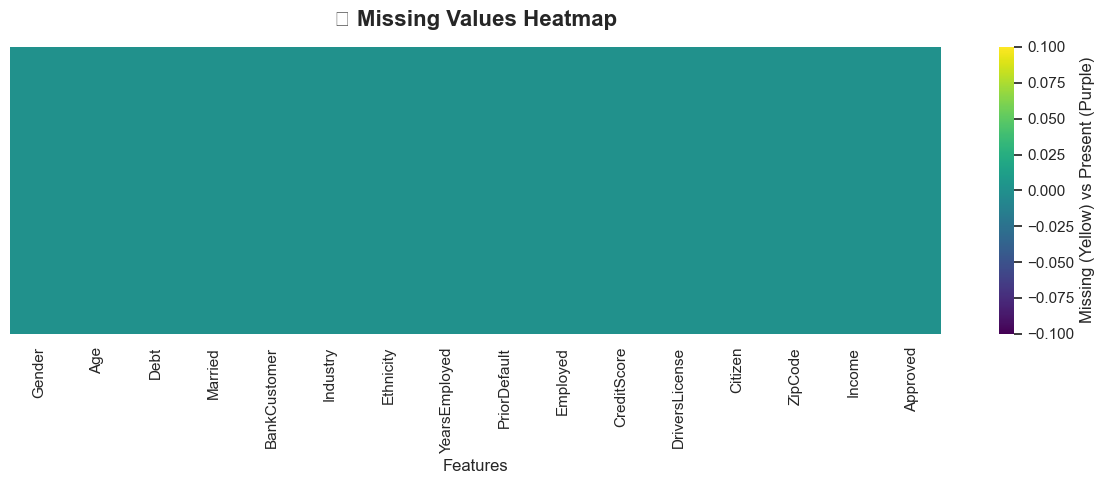

In [11]:
plt.figure(figsize=(12, 5))

# Heatmap of missing values
sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=True,
    cmap='viridis',
    cbar_kws={'label': 'Missing (Yellow) vs Present (Purple)'}
)

plt.title('🔍 Missing Values Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
#  Handle Missing Values
# ============================================================
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Fill numeric columns with median
numeric_cols = ['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
categorical_cols = ['Gender', 'Married', 'BankCustomer', 'Industry',
                    'Ethnicity', 'PriorDefault', 'Employed',
                    'DriversLicense', 'Citizen', 'ZipCode']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled!")
print(df.isnull().sum())

Missing values handled!
Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
Industry          0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64


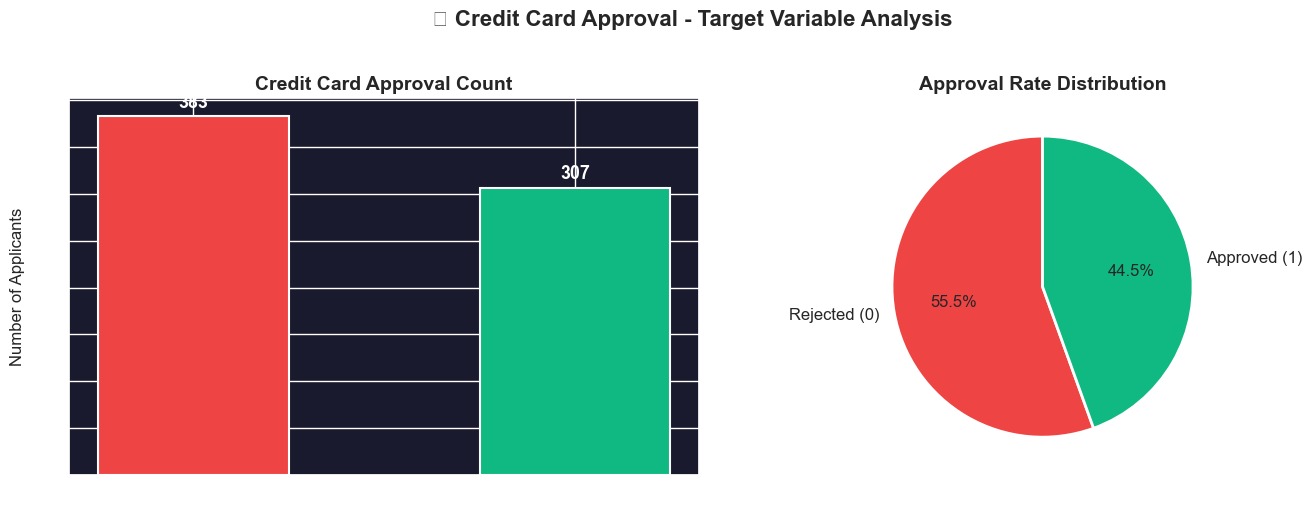

Approved: 307 (44.5%)
Rejected: 383 (55.5%)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Count Plot ---
colors = ['#ef4444', '#10b981']
counts = df['Approved'].value_counts()
labels = ['Rejected (0)', 'Approved (1)']

bars = axes[0].bar(labels, counts.values, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='white'
    )

axes[0].set_title('Credit Card Approval Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
axes[0].set_facecolor('#1a1a2e')
axes[0].tick_params(colors='white')

# --- Plot 2: Pie Chart ---
axes[1].pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
axes[1].set_title('Approval Rate Distribution', fontsize=14, fontweight='bold')

plt.suptitle('📊 Credit Card Approval - Target Variable Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Approved: {counts.get(1, 0)} ({counts.get(1,0)/len(df)*100:.1f}%)")
print(f"Rejected: {counts.get(0, 0)} ({counts.get(0,0)/len(df)*100:.1f}%)")

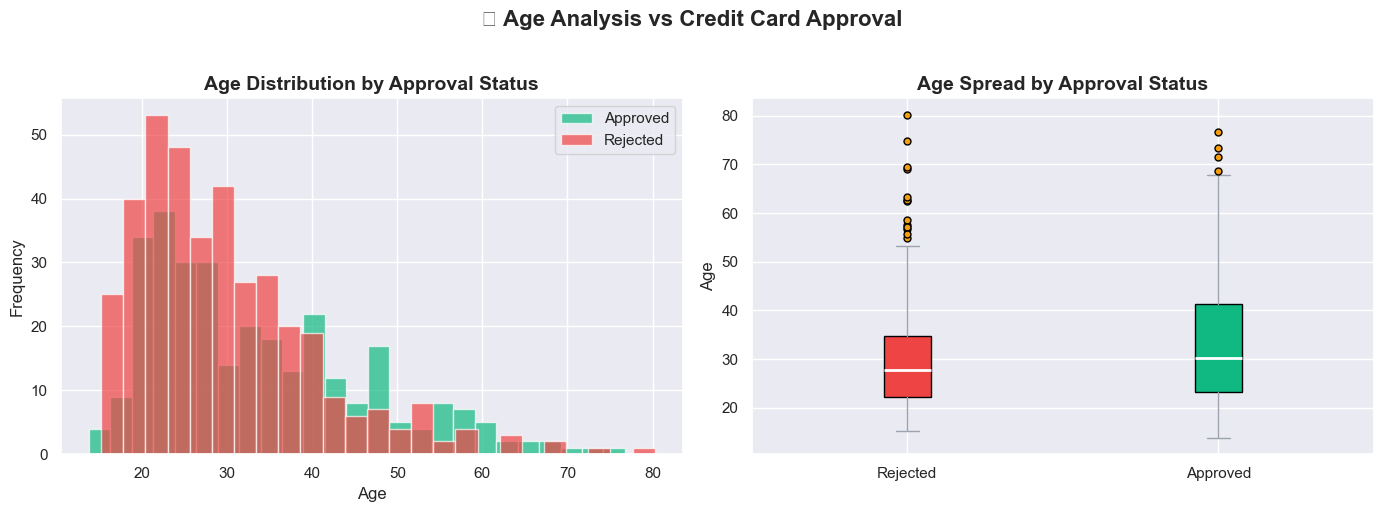

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Age Histogram by Approval ---
approved_ages = df[df['Approved'] == 1]['Age']
rejected_ages = df[df['Approved'] == 0]['Age']

axes[0].hist(approved_ages, bins=25, alpha=0.7, color='#10b981',
             label='Approved', edgecolor='white')
axes[0].hist(rejected_ages, bins=25, alpha=0.7, color='#ef4444',
             label='Rejected', edgecolor='white')
axes[0].set_title('Age Distribution by Approval Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# --- Plot 2: Box Plot ---
data_to_plot = [
    df[df['Approved'] == 0]['Age'].dropna(),
    df[df['Approved'] == 1]['Age'].dropna()
]
bp = axes[1].boxplot(
    data_to_plot,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#9ca3af'),
    capprops=dict(color='#9ca3af'),
    flierprops=dict(markerfacecolor='#f59e0b', marker='o', markersize=5)
)

# Set x tick labels separately (works on ALL versions)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Rejected', 'Approved'])

bp['boxes'][0].set_facecolor('#ef4444')
bp['boxes'][1].set_facecolor('#10b981')
axes[1].set_title('Age Spread by Approval Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Age')

plt.suptitle('👤 Age Analysis vs Credit Card Approval',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

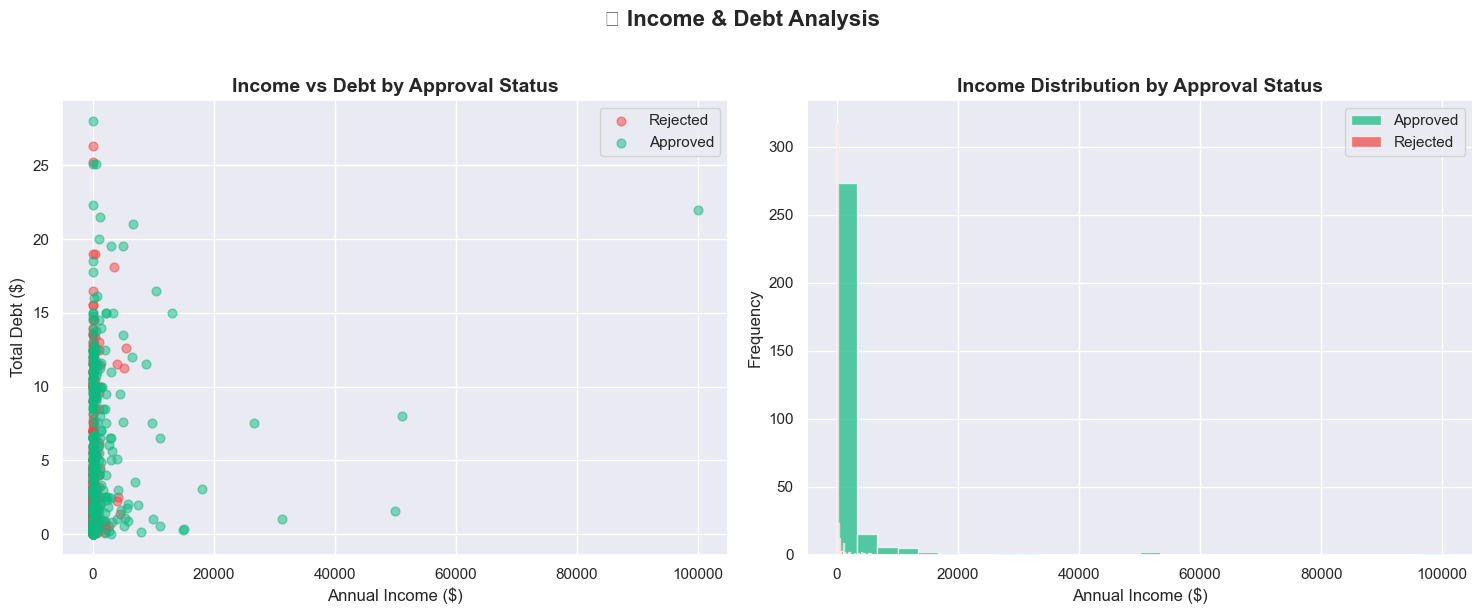

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Scatter Plot ---
approved = df[df['Approved'] == 1]
rejected = df[df['Approved'] == 0]

axes[0].scatter(rejected['Income'], rejected['Debt'],
                alpha=0.5, color='#ef4444', label='Rejected', s=40)
axes[0].scatter(approved['Income'], approved['Debt'],
                alpha=0.5, color='#10b981', label='Approved', s=40)
axes[0].set_title('Income vs Debt by Approval Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Annual Income ($)')
axes[0].set_ylabel('Total Debt ($)')
axes[0].legend()

# --- Plot 2: Income Distribution ---
axes[1].hist(approved['Income'], bins=30, alpha=0.7,
             color='#10b981', label='Approved', edgecolor='white')
axes[1].hist(rejected['Income'], bins=30, alpha=0.7,
             color='#ef4444', label='Rejected', edgecolor='white')
axes[1].set_title('Income Distribution by Approval Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Annual Income ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('💰 Income & Debt Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


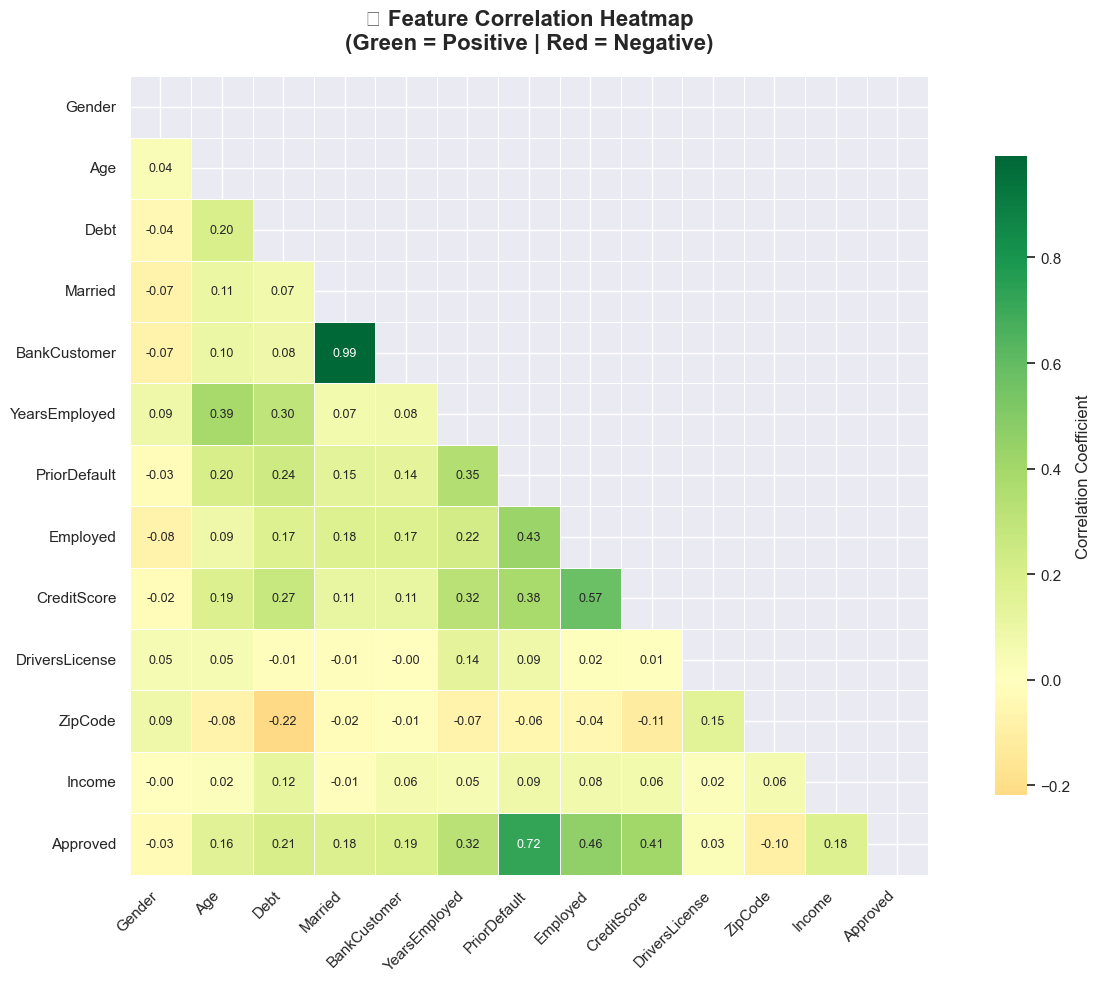

✅ Highly correlated features identified!


In [16]:
plt.figure(figsize=(14, 10))

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(
    correlation,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
    annot_kws={'size': 9}
)

plt.title('🔥 Feature Correlation Heatmap\n(Green = Positive | Red = Negative)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("✅ Highly correlated features identified!")

In [18]:
# Run this to confirm the flip
print("Current mapping check:")
print(f"0 count: {(df['Approved']==0).sum()} → This should be REJECTED")
print(f"1 count: {(df['Approved']==1).sum()} → This should be APPROVED")

# Check original CSV
df_original = pd.read_csv('clean_dataset.csv')
df_original.columns = [
    'Gender', 'Age', 'Debt', 'Married', 'BankCustomer',
    'Industry', 'Ethnicity', 'YearsEmployed', 'PriorDefault',
    'Employed', 'CreditScore', 'DriversLicense', 'Citizen',
    'ZipCode', 'Income', 'Approved'
]
print("\nOriginal CSV Approved column:")
print(df_original['Approved'].unique())
print(df_original['Approved'].value_counts())

Current mapping check:
0 count: 383 → This should be REJECTED
1 count: 307 → This should be APPROVED

Original CSV Approved column:
[1 0]
Approved
0    383
1    307
Name: count, dtype: int64


In [19]:
# ============================================================
# Flip the wrong mapping
# ============================================================

print("BEFORE FIX:")
print(df['Approved'].value_counts())

# Flip 0 and 1 because they were reversed
df['Approved'] = df['Approved'].map({0: 1, 1: 0})

print("\nAFTER FIX:")
print(df['Approved'].value_counts())
print(f"\nApproved (1): {(df['Approved']==1).sum()}")
print(f"Rejected (0): {(df['Approved']==0).sum()}")

assert df['Approved'].isin([0,1]).all(), "ERROR: Invalid values!"
assert (df['Approved']==1).sum() > 0,    "ERROR: No approved cases!"
assert (df['Approved']==0).sum() > 0,    "ERROR: No rejected cases!"
print("\n✅ Target encoding FIXED!")

BEFORE FIX:
Approved
0    383
1    307
Name: count, dtype: int64

AFTER FIX:
Approved
1    383
0    307
Name: count, dtype: int64

Approved (1): 383
Rejected (0): 307

✅ Target encoding FIXED!


In [20]:
# ============================================================
# ENCODE CATEGORICAL FEATURES + SAVE ENCODERS
# ============================================================
from sklearn.preprocessing import LabelEncoder

encoders = {}
encode_cols = ['Gender', 'Industry', 'Ethnicity', 'Citizen']

for col in encode_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"{col} classes: {le.classes_}")
    for i, cls in enumerate(le.classes_):
        print(f"   '{cls}' → {i}")

# Convert boolean-like columns to int
bool_cols = ['Married', 'BankCustomer', 'PriorDefault',
             'Employed', 'DriversLicense']
for col in bool_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# ZipCode to numeric
df['ZipCode'] = pd.to_numeric(df['ZipCode'], errors='coerce').fillna(0)

print("\n✅ Encoding complete!")
print(df.dtypes)

Gender classes: ['0' '1']
   '0' → 0
   '1' → 1
Industry classes: ['CommunicationServices' 'ConsumerDiscretionary' 'ConsumerStaples'
 'Education' 'Energy' 'Financials' 'Healthcare' 'Industrials'
 'InformationTechnology' 'Materials' 'Real Estate' 'Research' 'Transport'
 'Utilities']
   'CommunicationServices' → 0
   'ConsumerDiscretionary' → 1
   'ConsumerStaples' → 2
   'Education' → 3
   'Energy' → 4
   'Financials' → 5
   'Healthcare' → 6
   'Industrials' → 7
   'InformationTechnology' → 8
   'Materials' → 9
   'Real Estate' → 10
   'Research' → 11
   'Transport' → 12
   'Utilities' → 13
Ethnicity classes: ['Asian' 'Black' 'Latino' 'Other' 'White']
   'Asian' → 0
   'Black' → 1
   'Latino' → 2
   'Other' → 3
   'White' → 4
Citizen classes: ['ByBirth' 'ByOtherMeans' 'Temporary']
   'ByBirth' → 0
   'ByOtherMeans' → 1
   'Temporary' → 2

✅ Encoding complete!
Gender              int64
Age               float64
Debt              float64
Married             int64
BankCustomer        int64

In [21]:
# ============================================================
#  Save Encoders
# ============================================================
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(encoders, 'models/encoders.joblib')
print("Encoders saved!")

Encoders saved!


In [22]:
# ============================================================
# PREPARE FEATURES
# ============================================================

feature_cols = [
    'Gender', 'Age', 'Debt', 'Married', 'BankCustomer',
    'Industry', 'YearsEmployed', 'PriorDefault',
    'Employed', 'CreditScore', 'Citizen', 'Income'
]

X = df[feature_cols]
y = df['Approved']

print("Features shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())
print(f"\nApproved: {(y==1).sum()} | Rejected: {(y==0).sum()}")

Features shape: (690, 12)

Class distribution:
Approved
1    383
0    307
Name: count, dtype: int64

Approved: 383 | Rejected: 307


In [23]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Train samples : {len(X_train)}")
print(f"✅ Test samples  : {len(X_test)}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

# ============================================================
# TRAIN ALL 4 MODELS
# ============================================================
models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss',
                                         random_state=42)
}

results = {}
print("=" * 50)
print("TRAINING RESULTS")
print("=" * 50)

for name, mdl in models_dict.items():
    mdl.fit(X_train, y_train)
    y_pred = mdl.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"✅ {name}: {acc*100:.2f}%")

best_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_name}")
print(f"🏆 Accuracy  : {results[best_name]*100:.2f}%")

✅ Train samples : 552
✅ Test samples  : 138

Train class distribution:
Approved
1    306
0    246
Name: count, dtype: int64

Test class distribution:
Approved
1    77
0    61
Name: count, dtype: int64
TRAINING RESULTS
✅ Logistic Regression: 81.16%
✅ Decision Tree: 78.99%
✅ Random Forest: 83.33%
✅ XGBoost: 84.06%

🏆 Best Model: XGBoost
🏆 Accuracy  : 84.06%


In [24]:
# ============================================================
# BEST MODEL EVALUATION
# ============================================================
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_curve, auc)

best_model = models_dict[best_name]
y_pred_best = best_model.predict(X_test)
y_proba     = best_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print(f"BEST MODEL: {best_name}")
print("=" * 50)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)
print(f"\nTN={cm[0][0]} FP={cm[0][1]}")
print(f"FN={cm[1][0]} TP={cm[1][1]}")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_best,
    target_names=['Rejected', 'Approved']
))

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f}")

BEST MODEL: XGBoost

Confusion Matrix:
[[52  9]
 [13 64]]

TN=52 FP=9
FN=13 TP=64

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.80      0.85      0.83        61
    Approved       0.88      0.83      0.85        77

    accuracy                           0.84       138
   macro avg       0.84      0.84      0.84       138
weighted avg       0.84      0.84      0.84       138

AUC Score: 0.9125


In [25]:
# ============================================================
# Test Model With Correct Values
# ============================================================

print("=" * 50)
print("ENCODER MAPPINGS")
print("=" * 50)
for col, le in encoders.items():
    print(f"\n{col}: {list(le.classes_)}")

# ── Get correct encoded values directly from encoder ──
# Use index 0 and 1 directly instead of string names

gender_vals    = list(encoders['Gender'].classes_)
industry_vals  = list(encoders['Industry'].classes_)
citizen_vals   = list(encoders['Citizen'].classes_)

print(f"\nGender options   : {gender_vals}")
print(f"Industry options : {industry_vals}")
print(f"Citizen options  : {citizen_vals}")

# Use first and last values from actual encoder classes
gender_good    = encoders['Gender'].transform([gender_vals[0]])[0]
gender_bad     = encoders['Gender'].transform([gender_vals[-1]])[0]

industry_good  = encoders['Industry'].transform([industry_vals[0]])[0]
industry_bad   = encoders['Industry'].transform([industry_vals[-1]])[0]

citizen_good   = encoders['Citizen'].transform([citizen_vals[0]])[0]
citizen_bad    = encoders['Citizen'].transform([citizen_vals[-1]])[0]

print(f"\nUsing for GOOD applicant:")
print(f"  Gender   → '{gender_vals[0]}' = {gender_good}")
print(f"  Industry → '{industry_vals[0]}' = {industry_good}")
print(f"  Citizen  → '{citizen_vals[0]}' = {citizen_good}")

print(f"\nUsing for BAD applicant:")
print(f"  Gender   → '{gender_vals[-1]}' = {gender_bad}")
print(f"  Industry → '{industry_vals[-1]}' = {industry_bad}")
print(f"  Citizen  → '{citizen_vals[-1]}' = {citizen_bad}")

# ── Good Applicant ──
good_applicant = pd.DataFrame([{
    'Gender':        gender_good,
    'Age':           35.0,
    'Debt':          1.5,
    'Married':       1,
    'BankCustomer':  1,
    'Industry':      industry_good,
    'YearsEmployed': 5.0,
    'PriorDefault':  1,
    'Employed':      1,
    'CreditScore':   8.0,
    'Citizen':       citizen_good,
    'Income':        50000.0
}])[feature_cols]

# ── Bad Applicant ──
bad_applicant = pd.DataFrame([{
    'Gender':        gender_bad,
    'Age':           20.0,
    'Debt':          15.0,
    'Married':       0,
    'BankCustomer':  0,
    'Industry':      industry_bad,
    'YearsEmployed': 0.0,
    'PriorDefault':  0,
    'Employed':      0,
    'CreditScore':   0.0,
    'Citizen':       citizen_bad,
    'Income':        0.0
}])[feature_cols]

# ── Predict ──
good_pred = best_model.predict(good_applicant)[0]
good_prob = best_model.predict_proba(good_applicant)[0]

bad_pred  = best_model.predict(bad_applicant)[0]
bad_prob  = best_model.predict_proba(bad_applicant)[0]

print("\n" + "=" * 50)
print("TEST RESULTS")
print("=" * 50)

print(f"\nGood Applicant:")
print(f"  Result     : {'✅ APPROVED' if good_pred==1 else '❌ REJECTED'}")
print(f"  Confidence : {max(good_prob)*100:.1f}%")
print(f"  Raw proba  : Rejected={good_prob[0]:.3f} | Approved={good_prob[1]:.3f}")

print(f"\nBad Applicant:")
print(f"  Result     : {'✅ APPROVED' if bad_pred==1 else '❌ REJECTED'}")
print(f"  Confidence : {max(bad_prob)*100:.1f}%")
print(f"  Raw proba  : Rejected={bad_prob[0]:.3f} | Approved={bad_prob[1]:.3f}")

print("\n" + "=" * 50)
if good_pred == 1 and bad_pred == 0:
    print("🎉 Model working CORRECTLY!")
    print("✅ Proceed to save!")
elif good_pred == 0 and bad_pred == 1:
    print("⚠️ Still flipped - run CELL A again then retrain!")
else:
    print("⚠️ Unexpected result - paste output here!")
print("=" * 50)

ENCODER MAPPINGS

Gender: ['0', '1']

Industry: ['CommunicationServices', 'ConsumerDiscretionary', 'ConsumerStaples', 'Education', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'InformationTechnology', 'Materials', 'Real Estate', 'Research', 'Transport', 'Utilities']

Ethnicity: ['Asian', 'Black', 'Latino', 'Other', 'White']

Citizen: ['ByBirth', 'ByOtherMeans', 'Temporary']

Gender options   : ['0', '1']
Industry options : ['CommunicationServices', 'ConsumerDiscretionary', 'ConsumerStaples', 'Education', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'InformationTechnology', 'Materials', 'Real Estate', 'Research', 'Transport', 'Utilities']
Citizen options  : ['ByBirth', 'ByOtherMeans', 'Temporary']

Using for GOOD applicant:
  Gender   → '0' = 0
  Industry → 'CommunicationServices' = 0
  Citizen  → 'ByBirth' = 0

Using for BAD applicant:
  Gender   → '1' = 1
  Industry → 'Utilities' = 13
  Citizen  → 'Temporary' = 2

TEST RESULTS

Good Applicant:
  Result     : ❌ REJECTED

In [26]:
# ============================================================
#  Save Best Model + Feature Columns
# ============================================================
joblib.dump(best_model, 'models/card_model.joblib')
joblib.dump(feature_cols, 'models/feature_cols.joblib')
print(f"\n✅ Model saved: models/card_model.joblib")
print(f"✅ Features saved: models/feature_cols.joblib")
print(f"✅ Encoders saved: models/encoders.joblib")
print("\nAll files ready for Flask app!")


✅ Model saved: models/card_model.joblib
✅ Features saved: models/feature_cols.joblib
✅ Encoders saved: models/encoders.joblib

All files ready for Flask app!
